#**Pizza**

In [29]:
import numpy as np
import matplotlib.pyplot as plt

In [30]:
path = "/content/pizza.npy"
df = np.load(path) # shape: (N, 784)  uint8  [0,255]
N_TOTAL=len(df)
print(f"Total sketches:{N_TOTAL:,}")
print(f"Array shape: {df.shape}")
print(f"dtype:{df.dtype}")
print(f"Value range:[{df.min()}, {df.max()}]")

Total sketches:130,371
Array shape: (130371, 784)
dtype:uint8
Value range:[0, 255]


In [31]:
df.shape

(130371, 784)

In [32]:
import os

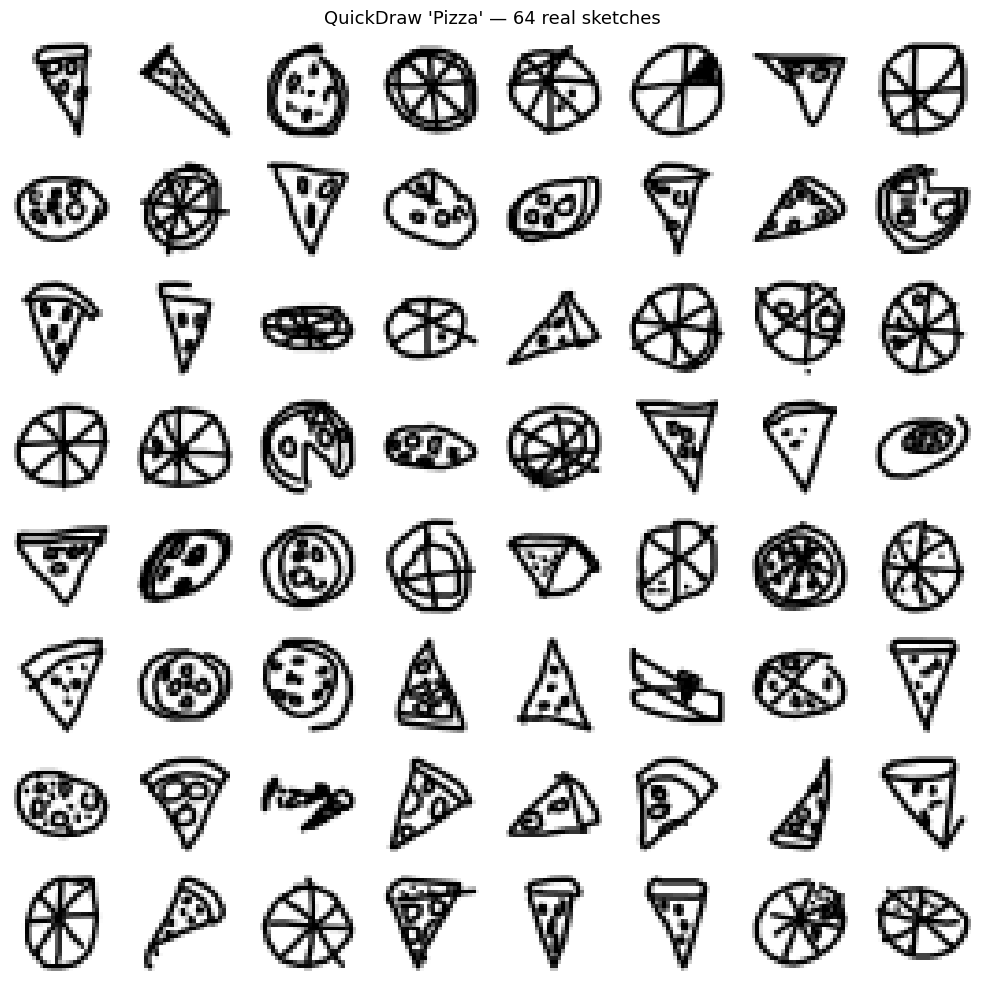

In [33]:
#samples
n_show = 64
idx = np.random.choice(N_TOTAL, n_show, replace=False)
sample = df[idx].reshape(-1, 28, 28)

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
fig.suptitle("QuickDraw 'Pizza' — 64 real sketches", fontsize=13)
for ax, img in zip(axes.ravel(), sample):
    ax.imshow(255 - img, cmap="gray", vmin=0, vmax=255)
    ax.axis("off")
plt.tight_layout()
os.makedirs('outputs', exist_ok=True)
plt.show()

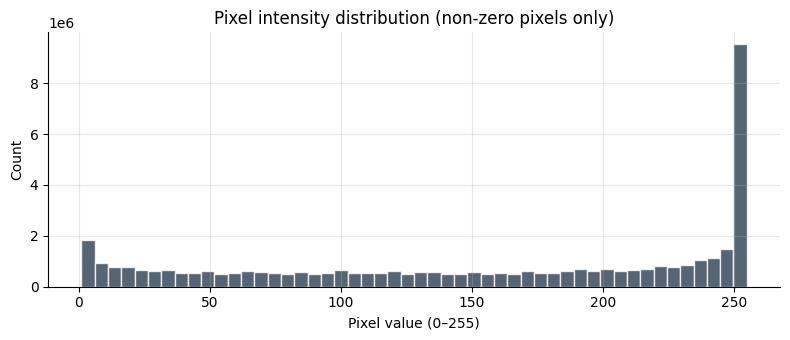

In [34]:
#distribution
fig, ax = plt.subplots(figsize=(8, 3.5))
nonzero = df[df > 0].ravel()
ax.hist(nonzero, bins=50, color="#2c3e50", alpha=0.8, edgecolor="white", lw=0.3)
ax.set_title("Pixel intensity distribution (non-zero pixels only)")
ax.set_xlabel("Pixel value (0–255)")
ax.set_ylabel("Count")
ax.spines[["top","right"]].set_visible(False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

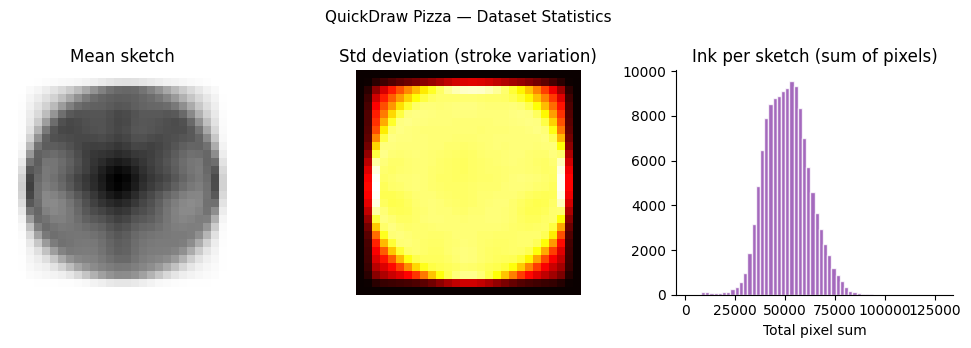

In [35]:
#dataset statistics
mean_img = df.mean(axis=0).reshape(28, 28)
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
axes[0].imshow(255 - mean_img, cmap="gray")
axes[0].set_title("Mean sketch"); axes[0].axis("off")

std_img = df.std(axis=0).reshape(28, 28)
axes[1].imshow(std_img, cmap="hot")
axes[1].set_title("Std deviation (stroke variation)"); axes[1].axis("off")

axes[2].hist(df.sum(axis=1), bins=60, color="#8e44ad", alpha=0.8, edgecolor="white")
axes[2].set_title("Ink per sketch (sum of pixels)")
axes[2].set_xlabel("Total pixel sum"); axes[2].spines[["top","right"]].set_visible(False)

plt.suptitle("QuickDraw Pizza — Dataset Statistics", fontsize=11)
plt.tight_layout()
plt.show()

In [36]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import numpy as np
import os

In [37]:
img_size=28
latent_dim=100
batch_size=128
EPOCHS=100      #200 for better results
LR=0.0002
BETA1=0.5
N_TRAIN=min(N_TOTAL, 50_000)   #cap for speed; use all for best quality

# invert colors (255 - df) and normalise to [-1, 1]
# This maps background to 1 (white) and ink to -1 (black)
imgs=(255-df[:N_TRAIN]).astype(np.float32) / 127.5 - 1.0   # (N, 784)
imgs=imgs.reshape(-1, 1, img_size, img_size) # (N, 1, 28, 28)

dataset=TensorDataset(torch.from_numpy(imgs))
dataloader=DataLoader(dataset, batch_size=batch_size,
                        shuffle=True, drop_last=True)
print(f"Training on {N_TRAIN:,} sketches  |  {len(dataloader)} batches/epoch")

Training on 50,000 sketches  |  390 batches/epoch


In [38]:
#weights intialisation
def weights_init(m):
    cname = m.__class__.__name__
    if "Conv" in cname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in cname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [39]:
#generator
class Generator(nn.Module):
    def __init__(self, z_dim=latent_dim, ngf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim,    ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*8,    ngf*4, 3, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4,    ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2,    1,     4, 2, 1, bias=False),
            nn.Tanh())

    def forward(self, z):
        return self.net(z)

In [40]:
#discriminator
class Discriminator(nn.Module):
    def __init__(self, ndf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,      ndf,   4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf,    ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*2,  ndf*4, 3, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*4,  1,     4, 1, 0, bias=False),
            nn.Sigmoid())

    def forward(self, x):
        return self.net(x).view(-1, 1)

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
G = Generator().to(device);G.apply(weights_init)
D = Discriminator().to(device);D.apply(weights_init)
print(f"Generator params: {sum(p.numel() for p in G.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in D.parameters()):,}")

Generator params: 2,526,976
Discriminator params: 431,872


In [42]:
criterion= nn.BCELoss()
opt_G=optim.Adam(G.parameters(), lr=LR, betas=(BETA1, 0.999))
opt_D=optim.Adam(D.parameters(), lr=LR, betas=(BETA1, 0.999))

REAL_LABEL=0.9# label smoothing
fixed_noise = torch.randn(64,latent_dim, 1, 1, device=device)

G_losses, D_losses = [], []
snapshots   = {}     # epoch → image grid

print(f"\nTraining DCGAN  ({EPOCHS} epochs) …\n")
for epoch in range(EPOCHS):
    g_run = d_run = 0.0

    for (real_imgs,) in dataloader:
        real_imgs= real_imgs.to(device)
        b= real_imgs.size(0)

        real_lbl = torch.full((b, 1), REAL_LABEL, device=device)
        fake_lbl = torch.zeros(b, 1,              device=device)

        #discriminator
        opt_D.zero_grad()
        loss_real = criterion(D(real_imgs), real_lbl)
        z         = torch.randn(b, latent_dim, 1, 1, device=device)
        fake_imgs = G(z)
        loss_fake = criterion(D(fake_imgs.detach()), fake_lbl)
        loss_D     = loss_real + loss_fake
        loss_D.backward(); opt_D.step()

        #generator
        opt_G.zero_grad()
        z         = torch.randn(b, latent_dim, 1, 1, device=device)
        fake_imgs = G(z)
        loss_G    = criterion(D(fake_imgs), real_lbl)
        loss_G.backward(); opt_G.step()
        d_run += loss_D.item()
        g_run += loss_G.item()

    n = len(dataloader)
    G_losses.append(g_run / n)
    D_losses.append(d_run / n)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        G.eval()
        with torch.no_grad():
            snaps = G(fixed_noise).cpu()
        G.train()
        snapshots[epoch + 1] = snaps
        print(f"  Epoch [{epoch+1:3d}/{EPOCHS}]  "
              f"D: {D_losses[-1]:.4f}  G: {G_losses[-1]:.4f}")

torch.save(G.state_dict(), "outputs/pizza_generator.pt")
torch.save(D.state_dict(), "outputs/pizza_discriminator.pt")


Training DCGAN  (100 epochs) …

  Epoch [  1/100]  D: 0.7299  G: 2.5779
  Epoch [ 10/100]  D: 0.5110  G: 3.2254
  Epoch [ 20/100]  D: 0.3816  G: 4.2076
  Epoch [ 30/100]  D: 0.4914  G: 3.4714
  Epoch [ 40/100]  D: 0.4457  G: 3.7769
  Epoch [ 50/100]  D: 0.5413  G: 3.0984
  Epoch [ 60/100]  D: 0.3920  G: 4.0141
  Epoch [ 70/100]  D: 0.4089  G: 4.0328
  Epoch [ 80/100]  D: 0.4412  G: 4.1264
  Epoch [ 90/100]  D: 0.4227  G: 3.8563
  Epoch [100/100]  D: 0.4513  G: 3.8490


In [43]:
N_TOTAL = len(df)
N_TRAIN    = 10000 #10,000 samples for quicker tuning

#hyoeroarameter grid
param_grid = {
    "lr": [0.0002, 0.0001],
    "latent_dim": [64, 100, 128],
    "batch_size": [128, 256],}

results = []

In [44]:
#weight initialisation
def weights_init(m):
    cname = m.__class__.__name__
    if "Conv" in cname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in cname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [45]:
#generator
class Generator(nn.Module):
    def __init__(self, z_dim, ngf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*8, ngf*4, 3, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, 1,     4, 2, 1, bias=False),
            nn.Tanh())
    def forward(self, z): return self.net(z)

In [46]:
#discriminator
class Discriminator(nn.Module):
    def __init__(self, ndf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,      ndf,   4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf,    ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*2,  ndf*4, 3, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*4,  1,     4, 1, 0, bias=False))
    def forward(self, x): return self.net(x).view(-1, 1)

In [47]:
#training loop
for lr in param_grid["lr"]:
    for latent_dim in param_grid["latent_dim"]:
        for batch_size in param_grid["batch_size"]:

            print(f"\nTesting: LR={lr}, Z={latent_dim}, BS={batch_size}")

            #recreate models
            G = Generator(latent_dim).to(device)
            D = Discriminator().to(device)
            #weights
            G.apply(weights_init)
            D.apply(weights_init)
            # Optimizers
            opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
            opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
            criterion = nn.BCEWithLogitsLoss()
            imgs = df[:N_TRAIN].astype(np.float32) / 127.5 - 1.0
            imgs = imgs.reshape(-1, 1, 28, 28)
            dataset = TensorDataset(torch.from_numpy(imgs))
            NUM_WORKERS = 2 if os.name != "nt" else 0
            dataloader = DataLoader(
                dataset,
                batch_size=batch_size,
                shuffle=True,
                drop_last=True,
                num_workers=NUM_WORKERS,
                pin_memory=(device.type == "cuda"),)

            #train for few epochs (quick tuning)
            epochs = 5
            for epoch in range(epochs):
                for (real_imgs,) in dataloader:
                    real_imgs = real_imgs.to(device)
                    b = real_imgs.size(0)
                    REAL_LABEL = 0.9
                    real_lbl = torch.full((b, 1), REAL_LABEL, device=device)
                    fake_lbl = torch.zeros(b, 1, device=device)
                    #discriminator
                    z = torch.randn(b, latent_dim, 1, 1).to(device)
                    fake_imgs = G(z)
                    loss_real = criterion(D(real_imgs), real_lbl)
                    loss_fake = criterion(D(fake_imgs.detach()), fake_lbl)
                    loss_D = loss_real + loss_fake
                    opt_D.zero_grad()
                    loss_D.backward()
                    opt_D.step()
                    #generator-
                    z = torch.randn(b, latent_dim, 1, 1).to(device)
                    fake_imgs = G(z)
                    loss_G = criterion(D(fake_imgs), real_lbl)
                    opt_G.zero_grad()
                    loss_G.backward()
                    opt_G.step()

            #store results
            results.append({
                "lr": lr,
                "latent_dim": latent_dim,
                "batch_size": batch_size,
                "D_loss": loss_D.item(),
                "G_loss": loss_G.item()})


Testing: LR=0.0002, Z=64, BS=128

Testing: LR=0.0002, Z=64, BS=256

Testing: LR=0.0002, Z=100, BS=128

Testing: LR=0.0002, Z=100, BS=256

Testing: LR=0.0002, Z=128, BS=128

Testing: LR=0.0002, Z=128, BS=256

Testing: LR=0.0001, Z=64, BS=128

Testing: LR=0.0001, Z=64, BS=256

Testing: LR=0.0001, Z=100, BS=128

Testing: LR=0.0001, Z=100, BS=256

Testing: LR=0.0001, Z=128, BS=128

Testing: LR=0.0001, Z=128, BS=256


In [48]:
#results
for r in results:
    print(r)

{'lr': 0.0002, 'latent_dim': 64, 'batch_size': 128, 'D_loss': 0.6220544576644897, 'G_loss': 1.8081222772598267}
{'lr': 0.0002, 'latent_dim': 64, 'batch_size': 256, 'D_loss': 0.7381905317306519, 'G_loss': 2.4867939949035645}
{'lr': 0.0002, 'latent_dim': 100, 'batch_size': 128, 'D_loss': 0.5777283906936646, 'G_loss': 2.2898197174072266}
{'lr': 0.0002, 'latent_dim': 100, 'batch_size': 256, 'D_loss': 0.7606182098388672, 'G_loss': 1.4277873039245605}
{'lr': 0.0002, 'latent_dim': 128, 'batch_size': 128, 'D_loss': 0.46195876598358154, 'G_loss': 2.4983530044555664}
{'lr': 0.0002, 'latent_dim': 128, 'batch_size': 256, 'D_loss': 0.6481707692146301, 'G_loss': 1.5537569522857666}
{'lr': 0.0001, 'latent_dim': 64, 'batch_size': 128, 'D_loss': 0.4729692339897156, 'G_loss': 2.0116541385650635}
{'lr': 0.0001, 'latent_dim': 64, 'batch_size': 256, 'D_loss': 0.6632049083709717, 'G_loss': 2.1424667835235596}
{'lr': 0.0001, 'latent_dim': 100, 'batch_size': 128, 'D_loss': 0.44556233286857605, 'G_loss': 2.340

In [49]:
#results to sortable list
results_sorted = sorted(results, key=lambda x: abs(x["D_loss"] - 0.69))
best = results_sorted[0]
print("Best configuration:")
print(best)

Best configuration:
{'lr': 0.0001, 'latent_dim': 100, 'batch_size': 256, 'D_loss': 0.6860041618347168, 'G_loss': 1.992700219154358}


In [50]:
#best params
lr = best["lr"]
latent_dim = best["latent_dim"]
batch_size = best["batch_size"]
print(f"Retraining with LR={lr}, Z={latent_dim}, BS={batch_size}")
#recreate models
G = Generator(latent_dim).to(device)
D = Discriminator().to(device)
G.apply(weights_init)
D.apply(weights_init)
opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
criterion = nn.BCEWithLogitsLoss()
#recreate dataloader
dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=2 if os.name != "nt" else 0,
    pin_memory=(device.type == "cuda"))
EPOCHS = 30

G_losses = []
D_losses = []

for epoch in range(EPOCHS):
    g_run = d_run = 0.0
    for (real_imgs,) in dataloader:
        real_imgs = real_imgs.to(device)
        b = real_imgs.size(0)
        real_lbl = torch.full((b, 1), 0.9, device=device)
        fake_lbl = torch.zeros(b, 1, device=device)

       #discriminator
        z = torch.randn(b, latent_dim, 1, 1).to(device)
        fake_imgs = G(z)
        loss_real = criterion(D(real_imgs), real_lbl)
        loss_fake = criterion(D(fake_imgs.detach()), fake_lbl)
        loss_D = loss_real + loss_fake
        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        #generator
        z = torch.randn(b, latent_dim, 1, 1).to(device)
        fake_imgs = G(z)
        loss_G = criterion(D(fake_imgs), real_lbl)
        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()
        d_run += loss_D.item()
        g_run += loss_G.item()

    G_losses.append(g_run / len(dataloader))
    D_losses.append(d_run / len(dataloader))

    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] | D: {D_losses[-1]:.4f} | G: {G_losses[-1]:.4f}")

Retraining with LR=0.0001, Z=100, BS=256
Epoch [5/30] | D: 0.6503 | G: 2.1861
Epoch [10/30] | D: 0.5422 | G: 2.4767
Epoch [15/30] | D: 0.5319 | G: 2.6536
Epoch [20/30] | D: 0.4761 | G: 2.5977
Epoch [25/30] | D: 0.5768 | G: 2.6353
Epoch [30/30] | D: 0.6868 | G: 2.2715


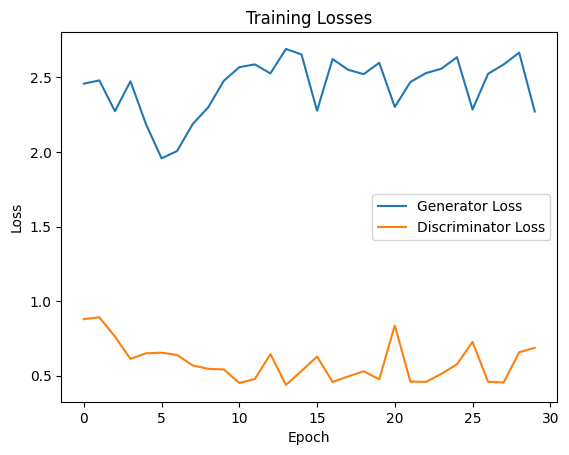

In [51]:
#loss curve
plt.figure()
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")
plt.legend()
plt.title("Training Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [52]:
import torchvision.utils as vutils

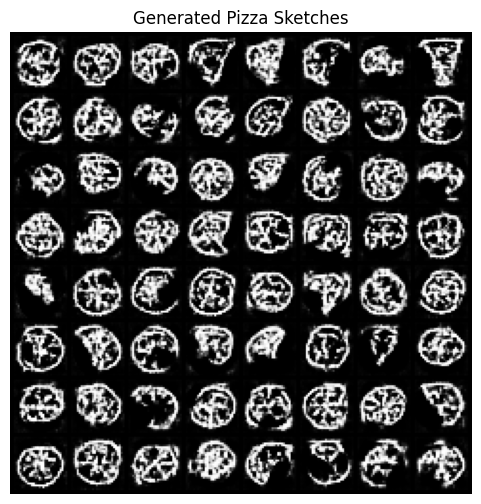

In [54]:
#generated images
G.eval()
with torch.no_grad():
    z = torch.randn(64, latent_dim, 1, 1).to(device)
    fake_imgs = G(z).cpu()

grid = vutils.make_grid(fake_imgs, nrow=8, normalize=True, value_range=(-1,1))
plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1,2,0))
plt.axis("off")
plt.title("Generated Pizza Sketches")
plt.show()

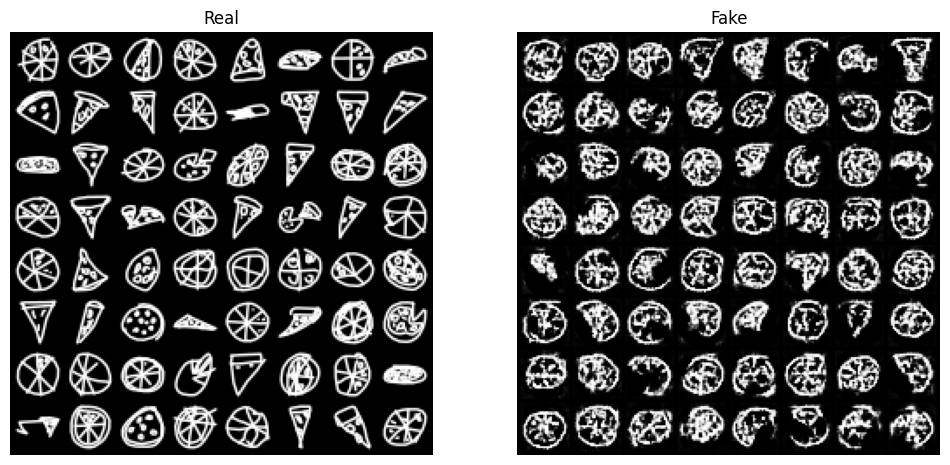

In [55]:
#real vs fake
real_imgs = next(iter(dataloader))[0][:64].cpu()
fig, axes = plt.subplots(1, 2, figsize=(12,6))
for ax, imgs, title in zip(axes,[real_imgs, fake_imgs],["Real", "Fake"]):
    grid = vutils.make_grid(imgs, nrow=8, normalize=True, value_range=(-1,1))
    ax.imshow(grid.permute(1,2,0))
    ax.set_title(title)
    ax.axis("off")
plt.show()

In [56]:
!pip install torch-fidelity

In [57]:
import os, shutil

shutil.rmtree("real", ignore_errors=True)
shutil.rmtree("fake", ignore_errors=True)
os.makedirs("real", exist_ok=True)
os.makedirs("fake", exist_ok=True)

In [58]:
#save real image
from torchvision.utils import save_image
count = 0
for (real_images,) in dataloader:
    real_images = real_images.to("cpu")
    for img in real_images:
        save_image(img, f"real/{count}.png",normalize=True, value_range=(-1,1))
        count += 1
        if count >= 1000:
            break
    if count >= 1000:
        break
print("Saved real images:", count)

Saved real images: 1000


In [60]:
#save fake images
G.eval()
count = 0
with torch.no_grad():
    while count < 1000:
        z = torch.randn(32, latent_dim, 1, 1).to(device)
        fake_images = G(z).cpu()

        for img in fake_images:
            save_image(img, f"fake/{count}.png",normalize=True, value_range=(-1,1))
            count += 1
            if count >= 1000:
                break
print("Saved fake images:", count)

Saved fake images: 1000


In [61]:
from torch_fidelity import calculate_metrics
#FID score
metrics = calculate_metrics(
    input1="real",
    input2="fake",
    cuda=True,
    fid=True)
print("FID Score:", metrics["frechet_inception_distance"])

Creating feature extractor "inception-v3-compat" with features ['2048']
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:01<00:00, 73.4MB/s]
Extracting statistics from input 1
Looking for samples non-recursivelty in "real" with extensions png,jpg,jpeg
Found 1000 samples
Processing samples
Extracting statistics from input 2
Looking for samples non-recursivelty in "fake" with extensions png,jpg,jpeg
Found 1000 samples
Processing samples


FID Score: 118.13836335600912


Frechet Inception Distance: 118.1384
